# Assignment 4

Assume you work for a record company. Your boss is interested in predicting ablum sales based on advertising. You are provided with the data in a file (*album_sales.csv*). 

There are 200 rows, where each row represents an album. There are also four columns. The first (*sales*) represents the sales of each album (in thousands) the week after release. The second (adverts) represents the amount (in thousands $) spent promoting the album prior to its release. The third (*airplay*) represents how many times it played on the radio. The fourth column (*attract*) represents the attractiveness of the band. 

## Instructions

### 1. Visualization (15 points)

Visualizing data is important to get a 'feel' of what the relationship between variables could be. For this part, **display the scatterplots between the following variables**.

- *sales* and *adverts*
- *sales* and *airplay*
- *sales* and *attract*

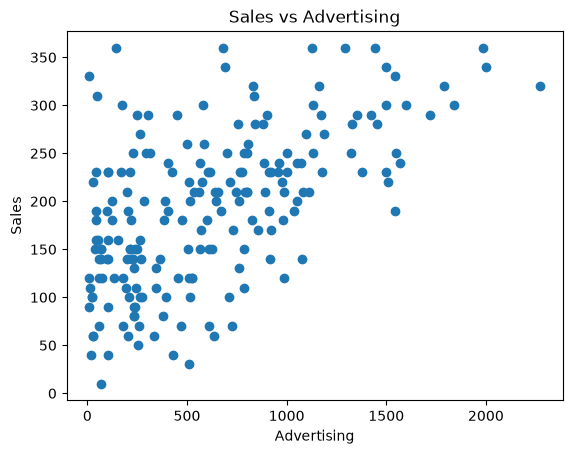

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('album_sales.csv')
df.head()

plt.scatter(df['adverts'], df['sales'])
plt.xlabel('Advertising')
plt.ylabel('Sales')
plt.title('Sales vs Advertising')
plt.show()

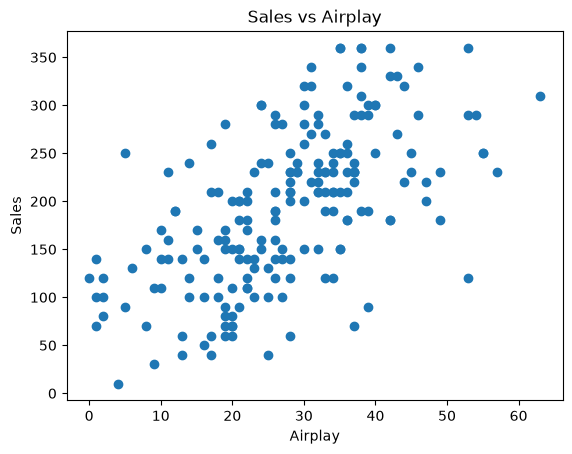

In [4]:
plt.scatter(df['airplay'], df['sales'])
plt.xlabel('Airplay')
plt.ylabel('Sales')
plt.title('Sales vs Airplay')
plt.show()

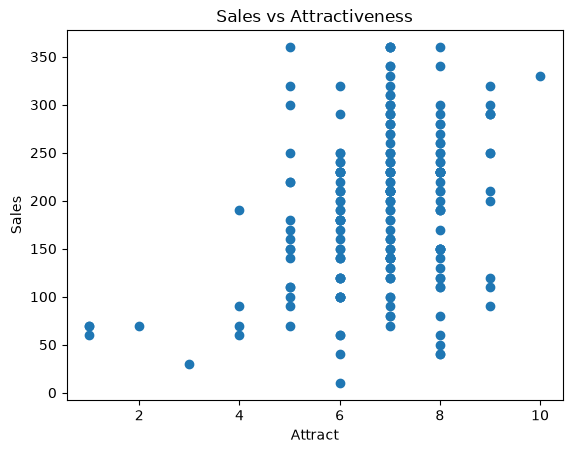

In [5]:
plt.scatter(df['attract'], df['sales'])
plt.xlabel('Attract')
plt.ylabel('Sales')
plt.title('Sales vs Attractiveness')
plt.show()

In the empty `Markdown` cell below, describe the relationship (or lack thereof) portrayed by the scatterplots you generated. 

The more that the company advertises, the more the sales increases. Theres a clear positive relationship within the scatterplot for Sales and Advertising.

With Sales and airplay, it displays a positive relatinoship between airplay and sales. As Airplay increases, album sales generally tend to increase.

With Sales and Attractiveness, there is a positive relationship but there is still a lot of variation.

### 2. Linear Regression (35 points)

- Conduct a linear regression to construct a linear model between *sales* and *adverts*
- Display the **F-statistic** and **P-value**
    - Use the `statsmodels.api` module for this -- may need to install via `pip`
    - Note that **X**, your predictor(s), will consist of *adverts* and that **y**, your constant, will consist of *sales*
    - The values you need can be accessed via the `summary()` function of your model object

In [6]:
import statsmodels.api as sm

X = df['adverts']
y = df['sales']

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.335
Model:                            OLS   Adj. R-squared:                  0.331
Method:                 Least Squares   F-statistic:                     99.59
Date:                Sun, 20 Sep 2026   Prob (F-statistic):           2.94e-19
Time:                        11:37:48   Log-Likelihood:                -1120.7
No. Observations:                 200   AIC:                             2245.
Df Residuals:                     198   BIC:                             2252.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        134.1399      7.537     17.799      0.0

In the empty `Markdown` cell below, describe whether the **F-statistic** and **P-value** describe about our linear regression model. (I.e., Is it good? Bad? No bearing?)

The F-statistic is used to evaluate the overall regression model, the model is using advertising to predict sales. With our P-value, there is a strong statiscal evidence that this advertising and album sales have a linear relationship in this dataset. The p-value bu itselt does not tell us how well the model predict sales, so we also need to consider the R-squared value when evaluating the model.

### 3. Model Coefficients (10 points)

- Make note of the **intercept** value and **coefficient** (adverts) value of your linear regression model. 

The regression line is described using this equation: *Y = b<sub>0</sub> + b<sub>1</sub>X<sub>1</sub>* where each variable represents the following:

- Y denotes the sales
- *b<sub>0</sub>* denotes the **intercept** value
- *b<sub>1</sub>* denotes the advertising budget **coefficient**
- *X<sub>2</sub>* denotes the advertising budget

The equation then becomes *Album Sales = intercept value + (coefficient * advertising budget)*. 

Using the intercept value and coefficient of your linear model, **calculate and display how many records will be sold if $135,000 was spent on advertising an album**.

In [7]:
intercept = model.params['const']
coefficient = model.params['adverts']

advertising = 135

predicted_sales = intercept + (coefficient * advertising)

print("Intercept:", intercept)
print("Advertising Coefficient:", coefficient)
print("Predicted Sales:", predicted_sales, "thousand albums")

Intercept: 134.13993781207427
Advertising Coefficient: 0.09612448597387711
Predicted Sales: 147.11674341854768 thousand albums


### 4. Multiple Regression (40 points)
- Conduct a **multiple regression** to construct a model between *sales* and the predictors (*adverts*, *airplay*, and *attract*)
    - Note that **X**, your predictors will consist of *adverts*, *airplay*, and *attractiveness*, and **y**, your constant, will consist of *sales*
- Display the summary of the multiple regression model using the `summary()` function to obtain the relevant values

In [8]:
X = df[['adverts', 'airplay', 'attract']]
y = df['sales']

X = sm.add_constant(X)

model2 = sm.OLS(y, X).fit()

print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.665
Model:                            OLS   Adj. R-squared:                  0.660
Method:                 Least Squares   F-statistic:                     129.5
Date:                Sun, 20 Sep 2026   Prob (F-statistic):           2.88e-46
Time:                        11:49:35   Log-Likelihood:                -1052.2
No. Observations:                 200   AIC:                             2112.
Df Residuals:                     196   BIC:                             2126.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -26.6130     17.350     -1.534      0.1

We know that the R<sup>2</sup> (R-Squared) value can be used to evaluate the overall fit of a linear model. We also know that R<sup>2</sup> is between 0 and 1 -- higher values are better because it means that more variance is explained by the model. **Higher R<sup>2</sup> values are better if their P-values are < 0.05**.

Bsed on this, discuss **which one of the two models you constructed is better** in the empty `Markdown` cell below. 
* Model 1: The linear model between *sales* and *adverts* you constructed
* Model 2: The multiple regression model between (*sales*) and the predictors (*adverts*, *airplay*, and *attract*) you constructed

Model 2, the multiple regression model using adverts, airplay, and attract, has a higher R^2 value than Model 1. Model 1 has an R^2 of 0.335, meaning it explains about 33.5% of the variation in album sales. Model 2 has an R^2 of 0.665, meaning it explains about 66.5% of the variation in album sales.  The p-value for Model 2 is 2.88e-46, which is much smaller than 0.05, so the overall model is statically significant. This is based on the higher R^2 and the statiscally significant p-value.

### Submission
- Submit this `Jupyter` file to D2L, renamed as **Last_First_Assignment4.ipynb** 
    - Replace '**Last**' and '**First**' with your first and last name